# Gesture MLP Training — HaGRID 6 classes
Ноутбук извлекает 2D MediaPipe landmarks из `external/hagrid_6classes`, обучает MLP, считает метрики на тестовой выборке и сохраняет checkpoint для `realtime_inference.py`.

In [1]:
from pathlib import Path
import random
import time

import cv2
from IPython.display import display
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.utils.data import DataLoader, Dataset


In [50]:
# Пути
PROJECT_ROOT = Path("/Users/a1111/Documents/schcool/diplom/gesture-control")
DATASET_DIR = PROJECT_ROOT / "external/hagrid_6classes"
TASK_MODEL_PATH = PROJECT_ROOT / "models/hand_landmarker.task"
LANDMARKS_CSV_PATH = PROJECT_ROOT / "data/landmarks/hagrid_6classes_landmarks.csv"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Соответствие папок HaGRID и меток модели.
CLASS_MAP = {
    "fist": "fist",
    "palm": "palm",
    "like": "thumbs_up",
    "dislike": "thumbs_down",
    "peace": "victory",
    "no_gesture": "no_gesture",
}
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")

# Извлечение landmarks из изображений.
# Поставьте MAX_IMAGES_PER_CLASS = None, чтобы обработать весь external/hagrid_6classes.
REBUILD_LANDMARKS = False
MAX_IMAGES_PER_CLASS = 25000
MAX_HANDS_PER_IMAGE = 1
LANDMARKER_DELEGATE = "CPU"
MIN_HAND_DETECTION_CONFIDENCE = 0.5
MIN_HAND_PRESENCE_CONFIDENCE = 0.5
MIN_TRACKING_CONFIDENCE = 0.5
PRINT_EVERY_IMAGES = 1000

# Воспроизводимость и разбиение данных
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Обучение
BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-3

# Архитектура MLP
HIDDEN_DIMS = (256, 128, 64)
DROPOUT = 0.30

# Веса классов
USE_BALANCED_CLASS_WEIGHTS = True
NO_GESTURE_WEIGHT_MULTIPLIER = 1.5

# Имена артефактов. realtime_inference.py сначала ищет именно этот файл модели.
MODEL_FILENAME = "mlp_hagrid_6classes.pth"
HISTORY_FILENAME = "train_history_hagrid_6classes.csv"
REPORT_FILENAME = "classification_report_hagrid_6classes.txt"
CM_FILENAME = "confusion_matrix_hagrid_6classes.png"

# Инференс использует такую же нормализацию landmarks.
FEATURE_MODE = "xy_only_normalized"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
LANDMARKS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATASET_DIR =", DATASET_DIR)
print("LANDMARKS_CSV_PATH =", LANDMARKS_CSV_PATH)


PROJECT_ROOT = /Users/a1111/Documents/schcool/diplom/gesture-control
DATASET_DIR = /Users/a1111/Documents/schcool/diplom/gesture-control/external/hagrid_6classes
LANDMARKS_CSV_PATH = /Users/a1111/Documents/schcool/diplom/gesture-control/data/landmarks/hagrid_6classes_landmarks.csv


In [51]:
assert DATASET_DIR.exists(), f"Не найдена папка с датасетом: {DATASET_DIR}"
assert TASK_MODEL_PATH.exists(), f"Не найден MediaPipe hand landmarker: {TASK_MODEL_PATH}"

rng = random.Random(RANDOM_STATE)
all_image_paths_by_class = {}
sampled_image_paths_by_class = {}
summary_rows = []

for source_label, model_label in CLASS_MAP.items():
    class_dir = DATASET_DIR / source_label
    assert class_dir.exists(), f"Не найдена папка класса: {class_dir}"

    paths = sorted(
        path for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    all_image_paths_by_class[source_label] = paths

    shuffled = paths.copy()
    rng.shuffle(shuffled)
    if MAX_IMAGES_PER_CLASS is not None:
        shuffled = shuffled[:MAX_IMAGES_PER_CLASS]
    sampled_image_paths_by_class[source_label] = shuffled

    summary_rows.append({
        "source_label": source_label,
        "model_label": model_label,
        "available_images": len(paths),
        "selected_images": len(shuffled),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
print("Selected total:", int(summary_df["selected_images"].sum()))


,source_label,model_label,available_images,selected_images
0,fist,fist,27755,25000
1,palm,palm,28366,25000
2,like,thumbs_up,27708,25000
3,dislike,thumbs_down,28514,25000
4,peace,victory,28301,25000
5,no_gesture,no_gesture,112691,25000


Selected total: 150000


In [52]:
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

metadata_cols = [
    "sample_id",
    "image_id",
    "label",
    "source_label",
    "hand_idx",
    "handedness",
    "handedness_score",
    "image_width",
    "image_height",
    "source",
    "image_path",
]
feature_cols = []
for i in range(21):
    feature_cols += [f"x{i}", f"y{i}"]


def landmarks_to_xy_row(hand_landmarks):
    row = []
    for lm in hand_landmarks:
        row.extend([float(lm.x), float(lm.y)])
    return row


def get_handedness(result, hand_idx):
    if result.handedness and hand_idx < len(result.handedness) and result.handedness[hand_idx]:
        category = result.handedness[hand_idx][0]
        return category.category_name, float(category.score)
    return "unknown", 0.0


def extract_landmarks_to_csv(output_csv_path):
    delegate = BaseOptions.Delegate[LANDMARKER_DELEGATE.upper()]
    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(TASK_MODEL_PATH), delegate=delegate),
        running_mode=VisionRunningMode.IMAGE,
        num_hands=MAX_HANDS_PER_IMAGE,
        min_hand_detection_confidence=MIN_HAND_DETECTION_CONFIDENCE,
        min_hand_presence_confidence=MIN_HAND_PRESENCE_CONFIDENCE,
        min_tracking_confidence=MIN_TRACKING_CONFIDENCE,
    )

    rows = []
    skipped_read = 0
    skipped_no_hand = 0
    started_at = time.time()

    with HandLandmarker.create_from_options(options) as landmarker:
        for source_label, model_label in CLASS_MAP.items():
            image_paths = sampled_image_paths_by_class[source_label]
            class_detected = 0
            class_started_at = time.time()

            for idx, image_path in enumerate(image_paths, start=1):
                bgr = cv2.imread(str(image_path))
                if bgr is None:
                    skipped_read += 1
                    continue

                image_height, image_width = bgr.shape[:2]
                rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
                rgb = np.ascontiguousarray(rgb)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
                result = landmarker.detect(mp_image)

                if not result.hand_landmarks:
                    skipped_no_hand += 1
                    continue

                for hand_idx, hand_landmarks in enumerate(result.hand_landmarks[:MAX_HANDS_PER_IMAGE]):
                    handedness, handedness_score = get_handedness(result, hand_idx)
                    image_id = image_path.stem
                    sample_id = f"hagrid6_{source_label}_{image_id}_{hand_idx}"
                    xy_row = landmarks_to_xy_row(hand_landmarks)

                    rows.append({
                        "sample_id": sample_id,
                        "image_id": image_id,
                        "label": model_label,
                        "source_label": source_label,
                        "hand_idx": hand_idx,
                        "handedness": handedness,
                        "handedness_score": handedness_score,
                        "image_width": image_width,
                        "image_height": image_height,
                        "source": "HaGRID_6classes",
                        "image_path": str(image_path.relative_to(PROJECT_ROOT)),
                        **dict(zip(feature_cols, xy_row)),
                    })
                    class_detected += 1

                if PRINT_EVERY_IMAGES and idx % PRINT_EVERY_IMAGES == 0:
                    print(f"{source_label}: {idx}/{len(image_paths)} images, rows={class_detected}")

            elapsed = time.time() - class_started_at
            print(f"{source_label}: rows={class_detected}, elapsed={elapsed:.1f}s")

    df_landmarks = pd.DataFrame(rows)
    if not df_landmarks.empty:
        df_landmarks = df_landmarks[metadata_cols + feature_cols]
    df_landmarks.to_csv(output_csv_path, index=False)

    total_elapsed = time.time() - started_at
    print("Saved landmarks:", output_csv_path)
    print("Rows:", len(df_landmarks))
    print("Skipped unreadable images:", skipped_read)
    print("Skipped images without detected hand:", skipped_no_hand)
    print(f"Total elapsed: {total_elapsed:.1f}s")

    return df_landmarks


if REBUILD_LANDMARKS or not LANDMARKS_CSV_PATH.exists():
    df = extract_landmarks_to_csv(LANDMARKS_CSV_PATH)
else:
    print("Using existing landmarks CSV:", LANDMARKS_CSV_PATH)
    df = pd.read_csv(LANDMARKS_CSV_PATH)


Using existing landmarks CSV: /Users/a1111/Documents/schcool/diplom/gesture-control/data/landmarks/hagrid_6classes_landmarks.csv


In [53]:
assert not df.empty, "После извлечения landmarks датасет пуст. Проверьте TASK_MODEL_PATH и изображения."

print("Shape:", df.shape)
print(df["label"].value_counts())
display(df.head())

missing_labels = sorted(set(CLASS_MAP.values()) - set(df["label"].unique()))
assert not missing_labels, f"В CSV нет строк для классов: {missing_labels}"


Shape: (137044, 53)
label
palm           24327
thumbs_up      23210
fist           22792
thumbs_down    22738
victory        22522
no_gesture     21455
Name: count, dtype: int64


,sample_id,image_id,label,source_label,hand_idx,handedness,handedness_score,image_width,image_height,source,...,x16,y16,x17,y17,x18,y18,x19,y19,x20,y20
0,hagrid6_fist_b30e26a4-7c47-43c8-b7b8-481fcc28b...,b30e26a4-7c47-43c8-b7b8-481fcc28b8cd,fist,fist,0,Left,0.994159,512,512,HaGRID_6classes,...,0.552447,0.572038,0.645626,0.454742,0.568461,0.386880,0.572266,0.496500,0.601658,0.542362
1,hagrid6_fist_cb7e73f0-1c5b-499c-8aee-7049da448...,cb7e73f0-1c5b-499c-8aee-7049da44843f,fist,fist,0,Left,0.964288,512,360,HaGRID_6classes,...,0.609144,0.357329,0.635493,0.331505,0.638227,0.302107,0.634847,0.343077,0.631700,0.358682
2,hagrid6_fist_4f58ffd7-7de5-4aee-87a2-2b4da77fe...,4f58ffd7-7de5-4aee-87a2-2b4da77fe4d7,fist,fist,0,Right,0.999259,408,318,HaGRID_6classes,...,0.339392,0.418226,0.298808,0.397413,0.309038,0.367364,0.319729,0.394901,0.319798,0.416691
3,hagrid6_fist_7fc57a41-b993-42f9-acae-8e216590b...,7fc57a41-b993-42f9-acae-8e216590b0fe,fist,fist,0,Right,0.994700,496,512,HaGRID_6classes,...,0.537366,0.520691,0.500563,0.457598,0.518097,0.445649,0.492173,0.490983,0.489337,0.487824
4,hagrid6_fist_e70e742d-1ead-4e76-ac10-23d3b0ff2...,e70e742d-1ead-4e76-ac10-23d3b0ff20e9,fist,fist,0,Right,0.997016,508,512,HaGRID_6classes,...,0.573556,0.471334,0.475630,0.420199,0.473309,0.372865,0.489936,0.441670,0.501155,0.464206


In [54]:
def preprocess_landmarks_xy(row_xy, handedness):
    pts = np.array(row_xy, dtype=np.float32).reshape(21, 2)

    wrist = pts[0].copy()
    pts = pts - wrist

    if isinstance(handedness, str) and handedness.lower() == "left":
        pts[:, 0] = -pts[:, 0]

    scale = np.linalg.norm(pts[9])
    if scale < 1e-6:
        scale = np.linalg.norm(pts[5])
    if scale < 1e-6:
        scale = 1.0

    pts = pts / scale
    return pts.reshape(-1)

X_list = []
for _, row in df.iterrows():
    row_xy = row[feature_cols].values
    handedness = row["handedness"]
    X_list.append(preprocess_landmarks_xy(row_xy, handedness))

X = np.stack(X_list).astype(np.float32)
y_text = df["label"].values

print("X shape:", X.shape)
print("y size:", len(y_text))


X shape: (137044, 42)
y size: 137044


In [55]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train_raw.shape, y_train.shape)
print("Test:", X_test_raw.shape, y_test.shape)
print("Classes:", list(label_encoder.classes_))


Train: (109635, 42) (109635,)
Test: (27409, 42) (27409,)
Classes: ['fist', 'no_gesture', 'palm', 'thumbs_down', 'thumbs_up', 'victory']


In [56]:
mean = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0)
std[std < 1e-8] = 1.0

X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std


In [57]:
class GestureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = GestureDataset(X_train, y_train)
test_ds = GestureDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


Train batches: 429
Test batches: 108


In [58]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT):
        super().__init__()

        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

if USE_BALANCED_CLASS_WEIGHTS:
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train,
    ).astype(np.float32)
else:
    class_weights = np.ones(len(label_encoder.classes_), dtype=np.float32)

if "no_gesture" in label_encoder.classes_:
    ng_idx = list(label_encoder.classes_).index("no_gesture")
    class_weights[ng_idx] *= NO_GESTURE_WEIGHT_MULTIPLIER

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(label_encoder.classes_, class_weights.cpu().numpy().round(3))))

model = MLP(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / max(len(train_loader), 1)

    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            targets.extend(yb.numpy().tolist())

    test_acc = accuracy_score(targets, preds)
    test_macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)

    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "test_acc": test_acc,
        "test_macro_f1": test_macro_f1,
    })

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"loss={avg_loss:.4f} | test_acc={test_acc:.4f} | test_macro_f1={test_macro_f1:.4f}"
    )


Device: mps
Class weights: {'fist': np.float32(1.002), 'no_gesture': np.float32(1.597), 'palm': np.float32(0.939), 'thumbs_down': np.float32(1.005), 'thumbs_up': np.float32(0.984), 'victory': np.float32(1.014)}
Epoch 01/30 | loss=1.6849 | test_acc=0.5342 | test_macro_f1=0.4371
Epoch 02/30 | loss=1.3818 | test_acc=0.8342 | test_macro_f1=0.8237
Epoch 03/30 | loss=1.0506 | test_acc=0.8766 | test_macro_f1=0.8660
Epoch 04/30 | loss=0.7628 | test_acc=0.9396 | test_macro_f1=0.9388
Epoch 05/30 | loss=0.5558 | test_acc=0.9576 | test_macro_f1=0.9571
Epoch 06/30 | loss=0.4192 | test_acc=0.9635 | test_macro_f1=0.9630
Epoch 07/30 | loss=0.3237 | test_acc=0.9672 | test_macro_f1=0.9668
Epoch 08/30 | loss=0.2571 | test_acc=0.9723 | test_macro_f1=0.9719
Epoch 09/30 | loss=0.2102 | test_acc=0.9768 | test_macro_f1=0.9765
Epoch 10/30 | loss=0.1767 | test_acc=0.9787 | test_macro_f1=0.9785
Epoch 11/30 | loss=0.1550 | test_acc=0.9808 | test_macro_f1=0.9806
Epoch 12/30 | loss=0.1387 | test_acc=0.9827 | test_m

TEST ACCURACY: 0.9871939873764092
TEST MACRO F1: 0.9869865064625563

              precision    recall  f1-score   support

        fist     0.9941    0.9906    0.9923      4558
  no_gesture     0.9621    0.9751    0.9685      4291
        palm     0.9868    0.9975    0.9921      4866
 thumbs_down     0.9962    0.9818    0.9889      4548
   thumbs_up     0.9877    0.9877    0.9877      4642
     victory     0.9955    0.9891    0.9923      4504

    accuracy                         0.9872     27409
   macro avg     0.9871    0.9870    0.9870     27409
weighted avg     0.9873    0.9872    0.9872     27409



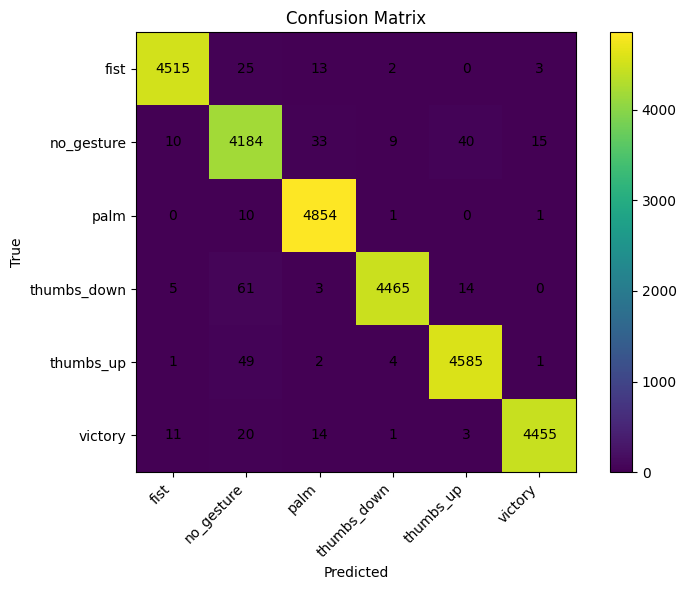

no_gesture precision: 0.9621
no_gesture recall: 0.9751


In [59]:
model.eval()
preds = []
targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        preds.extend(pred.tolist())
        targets.extend(yb.numpy().tolist())

acc = accuracy_score(targets, preds)
macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)

print("TEST ACCURACY:", acc)
print("TEST MACRO F1:", macro_f1)
print()
report = classification_report(targets, preds, target_names=label_encoder.classes_, digits=4, zero_division=0)
print(report)

cm = confusion_matrix(targets, preds)
fig = plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(label_encoder.classes_))
plt.xticks(ticks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(ticks, label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

if "no_gesture" in label_encoder.classes_:
    ng_idx = list(label_encoder.classes_).index("no_gesture")
    ng_tp = cm[ng_idx, ng_idx]
    ng_recall = ng_tp / max(cm[ng_idx, :].sum(), 1)
    ng_precision = ng_tp / max(cm[:, ng_idx].sum(), 1)

    print("no_gesture precision:", round(ng_precision, 4))
    print("no_gesture recall:", round(ng_recall, 4))


,epoch,train_loss,test_acc,test_macro_f1
20,21,0.088874,0.986245,0.986037
21,22,0.087184,0.986391,0.986183
22,23,0.084410,0.986537,0.986333
23,24,0.084325,0.986610,0.986405
24,25,0.081469,0.986720,0.986513
25,26,0.079960,0.986683,0.986473
26,27,0.080466,0.986720,0.986508
27,28,0.079085,0.987048,0.986841
28,29,0.079031,0.987121,0.986915
29,30,0.076330,0.987194,0.986987


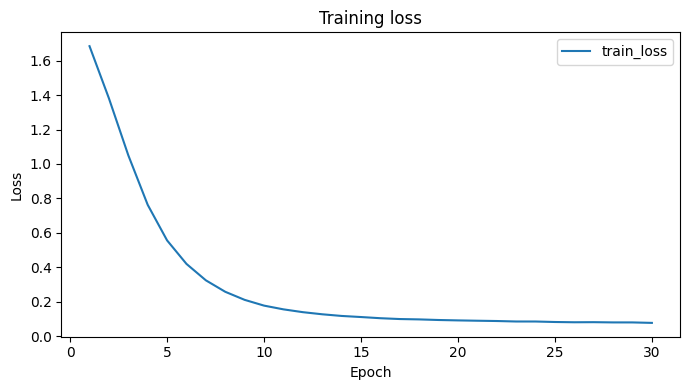

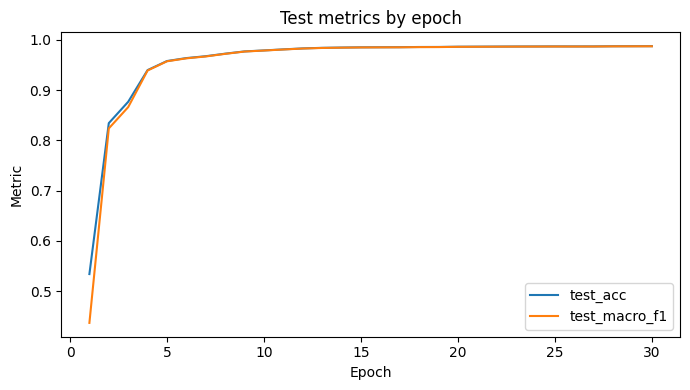

In [60]:
history_df = pd.DataFrame(history)
display(history_df.tail(10))

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["test_acc"], label="test_acc")
plt.plot(history_df["epoch"], history_df["test_macro_f1"], label="test_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Test metrics by epoch")
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
cm = confusion_matrix(targets, preds)

fig = plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(label_encoder.classes_))
plt.xticks(ticks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(ticks, label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(REPORTS_DIR / CM_FILENAME, dpi=200, bbox_inches="tight")
plt.close(fig)

history_df.to_csv(REPORTS_DIR / HISTORY_FILENAME, index=False)

with open(REPORTS_DIR / REPORT_FILENAME, "w", encoding="utf-8") as f:
    f.write(f"TEST ACCURACY: {acc:.6f}\n")
    f.write(f"TEST MACRO F1: {macro_f1:.6f}\n\n")
    f.write(report)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_classes": label_encoder.classes_.tolist(),
        "mean": mean.tolist(),
        "std": std.tolist(),
        "feature_mode": FEATURE_MODE,
        "source_dataset": str(DATASET_DIR.relative_to(PROJECT_ROOT)),
        "landmarks_csv_path": str(LANDMARKS_CSV_PATH.relative_to(PROJECT_ROOT)),
        "class_map": CLASS_MAP,
        "model_config": {
            "input_dim": int(X_train.shape[1]),
            "hidden_dims": list(HIDDEN_DIMS),
            "dropout": float(DROPOUT),
            "num_classes": int(len(label_encoder.classes_)),
        },
        "training_config": {
            "random_state": RANDOM_STATE,
            "test_size": TEST_SIZE,
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "use_balanced_class_weights": USE_BALANCED_CLASS_WEIGHTS,
            "no_gesture_multiplier": NO_GESTURE_WEIGHT_MULTIPLIER,
            "max_images_per_class": MAX_IMAGES_PER_CLASS,
        },
        "landmarker_config": {
            "max_hands_per_image": MAX_HANDS_PER_IMAGE,
            "delegate": LANDMARKER_DELEGATE,
            "min_hand_detection_confidence": MIN_HAND_DETECTION_CONFIDENCE,
            "min_hand_presence_confidence": MIN_HAND_PRESENCE_CONFIDENCE,
            "min_tracking_confidence": MIN_TRACKING_CONFIDENCE,
        },
    },
    MODELS_DIR / MODEL_FILENAME,
)

print("Saved model:", MODELS_DIR / MODEL_FILENAME)
print("Saved history:", REPORTS_DIR / HISTORY_FILENAME)
print("Saved report:", REPORTS_DIR / REPORT_FILENAME)
print("Saved confusion matrix:", REPORTS_DIR / CM_FILENAME)


Saved model: /Users/a1111/Documents/schcool/diplom/gesture-control/models/mlp_hagrid_6classes.pth
Saved history: /Users/a1111/Documents/schcool/diplom/gesture-control/reports/train_history_hagrid_6classes.csv
Saved report: /Users/a1111/Documents/schcool/diplom/gesture-control/reports/classification_report_hagrid_6classes.txt
Saved confusion matrix: /Users/a1111/Documents/schcool/diplom/gesture-control/reports/confusion_matrix_hagrid_6classes.png
